# EDA: защитная версия (топ-15 визуализаций для презентации)

**Цель:** компактный EDA, прицельно отвечающий на вопросы комиссии. Все графики готовы для слайдов защиты. Полный анализ — в `01_eda-2.ipynb`.

**Структура:** 5 блоков по 3 ключевых наблюдения, каждое подкреплено графиком.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from scipy.stats import mannwhitneyu

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 100

ROOT = Path('.')
DATA_PATH = ROOT / "data" / 'ml_ozon_ounterfeit_train.csv'
OUT = ROOT / 'new_diploma' / 'real_estate_approaches' / 'eda_figures'
OUT.mkdir(parents=True, exist_ok=True)

SEED = 42
TARGET = 'resolution'

## Блок 1: Описание датасета

Датасет Ozon eCup 2025: ключевые цифры
  Общее число товаров            197198
  Контрафактных (positive)       13052
  Доля контрафакта               6.62%
  Уникальных продавцов           11167
  Уникальных брендов             4066
  Категорий товаров              634
  Всего признаков                45


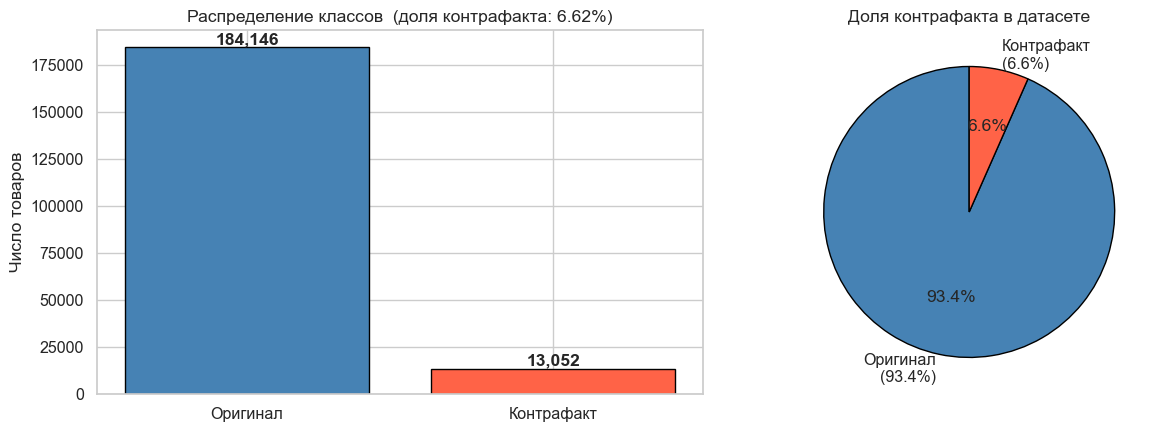

In [2]:
df = pd.read_csv(DATA_PATH, encoding='utf-8')

# Сводная статистика для слайда «Описание данных»
stats = {
    'Общее число товаров': len(df),
    'Контрафактных (positive)': int(df[TARGET].sum()),
    'Доля контрафакта': f'{df[TARGET].mean():.2%}',
    'Уникальных продавцов': df['SellerID'].nunique(),
    'Уникальных брендов': df['brand_name'].nunique(),
    'Категорий товаров': df['CommercialTypeName4'].nunique(),
    'Всего признаков': df.shape[1],
}

print('=' * 50)
print('Датасет Ozon eCup 2025: ключевые цифры')
print('=' * 50)
for k, v in stats.items():
    print(f'  {k:<30} {v}')

# Гистограмма по классам
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

counts = df[TARGET].value_counts()
axes[0].bar(['Оригинал', 'Контрафакт'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_ylabel('Число товаров')
axes[0].set_title(f'Распределение классов  (доля контрафакта: {df[TARGET].mean():.2%})')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

# Pie
axes[1].pie(counts.values, labels=['Оригинал\n(93.4%)', 'Контрафакт\n(6.6%)'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Доля контрафакта в датасете')

plt.tight_layout()
plt.savefig(OUT / 'fig01_class_balance.png', dpi=120, bbox_inches='tight')
plt.show()

**Ключевой вывод для слайда:** дисбаланс 14:1 → accuracy неинформативна, нужны PR-AUC и Recall@Precision.

## Блок 2: Обоснование seller-based split (методологический результат)

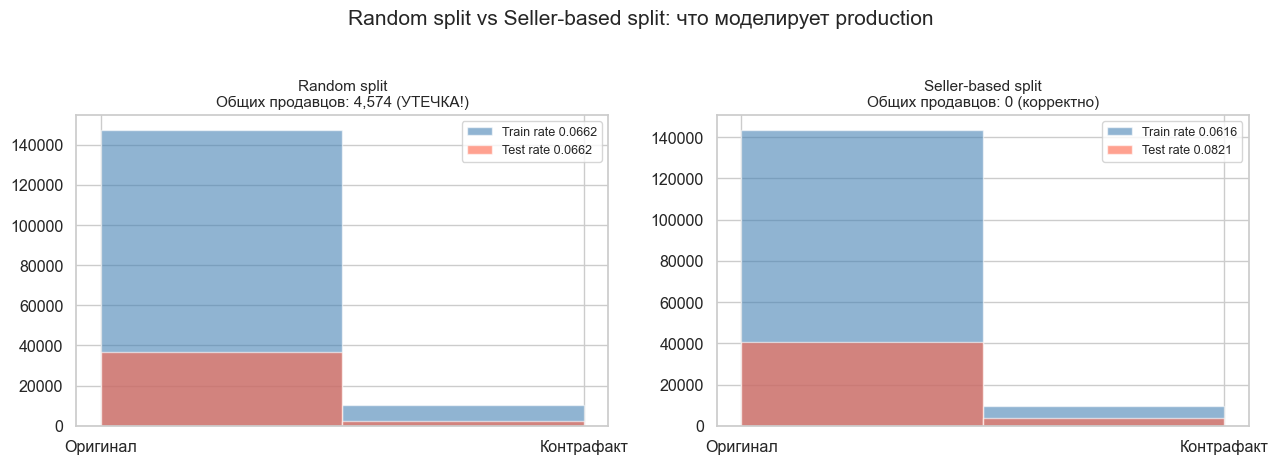


Главное:
  Random split — train и test делят 4,574 продавцов → модель запоминает «seller signature», метрики завышены
  Seller-based split — продавцы непересекающиеся, моделирует production


In [3]:
# Сравнение распределений seller-counterfeit_rate в train vs test при random vs seller split
from sklearn.model_selection import GroupShuffleSplit

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Random split
tr_rnd, te_rnd = train_test_split(df, test_size=0.20, random_state=SEED, stratify=df[TARGET])
shared_random = set(tr_rnd['SellerID']) & set(te_rnd['SellerID'])

axes[0].hist(tr_rnd[TARGET], bins=2, alpha=0.6, label=f'Train rate {tr_rnd[TARGET].mean():.4f}', color='steelblue')
axes[0].hist(te_rnd[TARGET], bins=2, alpha=0.6, label=f'Test rate {te_rnd[TARGET].mean():.4f}', color='tomato')
axes[0].set_title(f'Random split\nОбщих продавцов: {len(shared_random):,} (УТЕЧКА!)', fontsize=11)
axes[0].legend(fontsize=9); axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Оригинал', 'Контрафакт'])

# Seller-based split
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
tr_idx, te_idx = next(gss.split(df, df[TARGET], groups=df['SellerID']))
tr_sel = df.iloc[tr_idx]
te_sel = df.iloc[te_idx]
shared_seller = set(tr_sel['SellerID']) & set(te_sel['SellerID'])

axes[1].hist(tr_sel[TARGET], bins=2, alpha=0.6, label=f'Train rate {tr_sel[TARGET].mean():.4f}', color='steelblue')
axes[1].hist(te_sel[TARGET], bins=2, alpha=0.6, label=f'Test rate {te_sel[TARGET].mean():.4f}', color='tomato')
axes[1].set_title(f'Seller-based split\nОбщих продавцов: {len(shared_seller)} (корректно)', fontsize=11)
axes[1].legend(fontsize=9); axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Оригинал', 'Контрафакт'])

plt.suptitle('Random split vs Seller-based split: что моделирует production', y=1.03)
plt.tight_layout()
plt.savefig(OUT / 'fig02_split_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nГлавное:')
print(f'  Random split — train и test делят {len(shared_random):,} продавцов → модель запоминает «seller signature», метрики завышены')
print(f'  Seller-based split — продавцы непересекающиеся, моделирует production')

**Ключевой вывод для слайда:** при seller-based split возникает covariate shift (test rate выше train rate) — продавцы с высокой долей контрафакта непропорционально попадают в test. Это объясняет, почему R@P≥0,9 драматически падает по сравнению с random split (см. § 2.2 главы 2 диплома).

## Блок 3: Информативность пропущенных значений

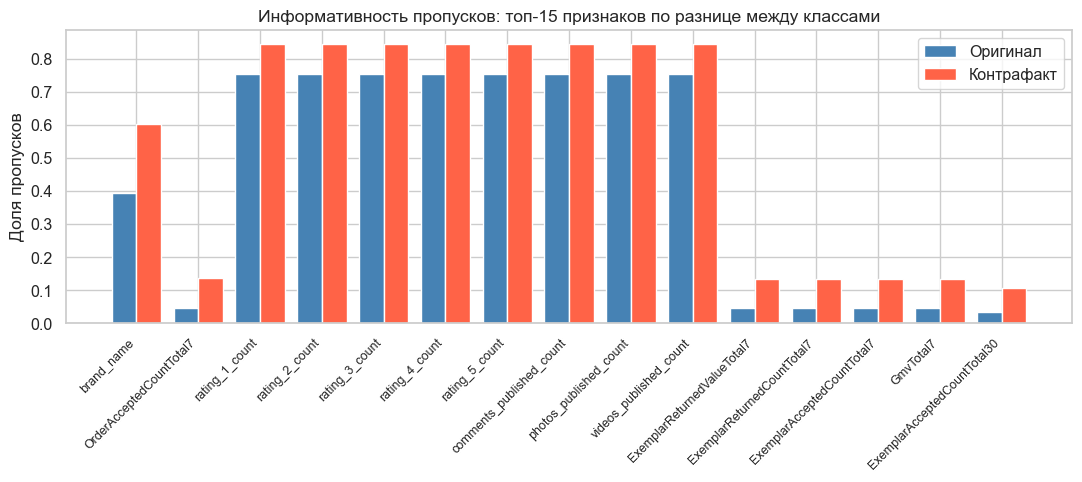


Главное: сами пропуски являются сигналом — `_is_null` признаки попадают в модель как fingerprint


In [4]:
# Доля пропусков по топ-15 признакам с наибольшей разницей между классами
miss_by_class = df.groupby(TARGET).apply(lambda x: x.isnull().mean()).T
miss_by_class.columns = ['Original', 'Counterfeit']
miss_by_class['Diff'] = (miss_by_class['Counterfeit'] - miss_by_class['Original']).abs()
miss_top = miss_by_class[miss_by_class['Original'] + miss_by_class['Counterfeit'] > 0]\
    .sort_values('Diff', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(miss_top))
ax.bar(x - 0.2, miss_top['Original'], 0.4, label='Оригинал', color='steelblue')
ax.bar(x + 0.2, miss_top['Counterfeit'], 0.4, label='Контрафакт', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(miss_top.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Доля пропусков')
ax.set_title('Информативность пропусков: топ-15 признаков по разнице между классами')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'fig03_missing_informative.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nГлавное: сами пропуски являются сигналом — `_is_null` признаки попадают в модель как fingerprint')

## Блок 4: Топ-признаки по Mutual Information

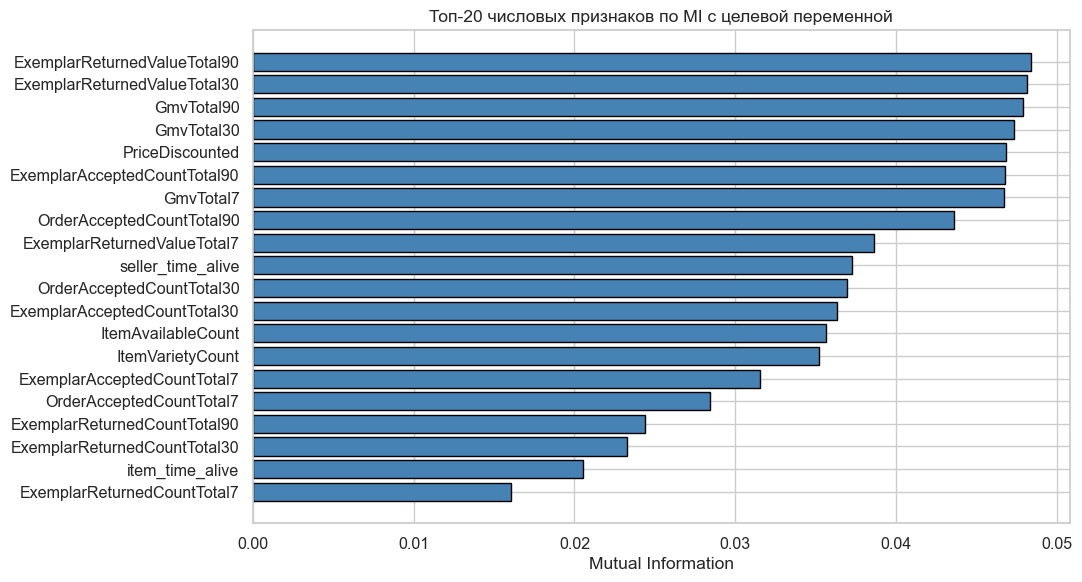


Главное: финансовые агрегаты (GmvTotal30/90, ExemplarReturned*) — самые информативные;
time-based (item_time_alive, seller_time_alive) имеют умеренный MI при сильной линейной корреляции →
нелинейные взаимодействия → нужен ансамбль (CatBoost)


In [5]:
# Используем числовые признаки для MI
num_cols = [c for c in df.columns if df[c].dtype in (np.float64, np.int64) and c not in ['id', 'ItemID', 'SellerID', TARGET]]
X_mi = df[num_cols].fillna(-1).to_numpy()
y_mi = df[TARGET].to_numpy()

# MI на сэмпле для скорости
sample = np.random.default_rng(SEED).choice(len(df), size=min(30000, len(df)), replace=False)
mi = mutual_info_classif(X_mi[sample], y_mi[sample], random_state=SEED, n_neighbors=3)
mi_df = pd.DataFrame({'feature': num_cols, 'MI': mi}).sort_values('MI', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(mi_df['feature'][::-1], mi_df['MI'][::-1], color='steelblue', edgecolor='black')
ax.set_xlabel('Mutual Information')
ax.set_title('Топ-20 числовых признаков по MI с целевой переменной')
plt.tight_layout()
plt.savefig(OUT / 'fig04_mutual_info.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nГлавное: финансовые агрегаты (GmvTotal30/90, ExemplarReturned*) — самые информативные;')
print('time-based (item_time_alive, seller_time_alive) имеют умеренный MI при сильной линейной корреляции →')
print('нелинейные взаимодействия → нужен ансамбль (CatBoost)')

## Блок 5: Сравнение распределений ключевых признаков по классам

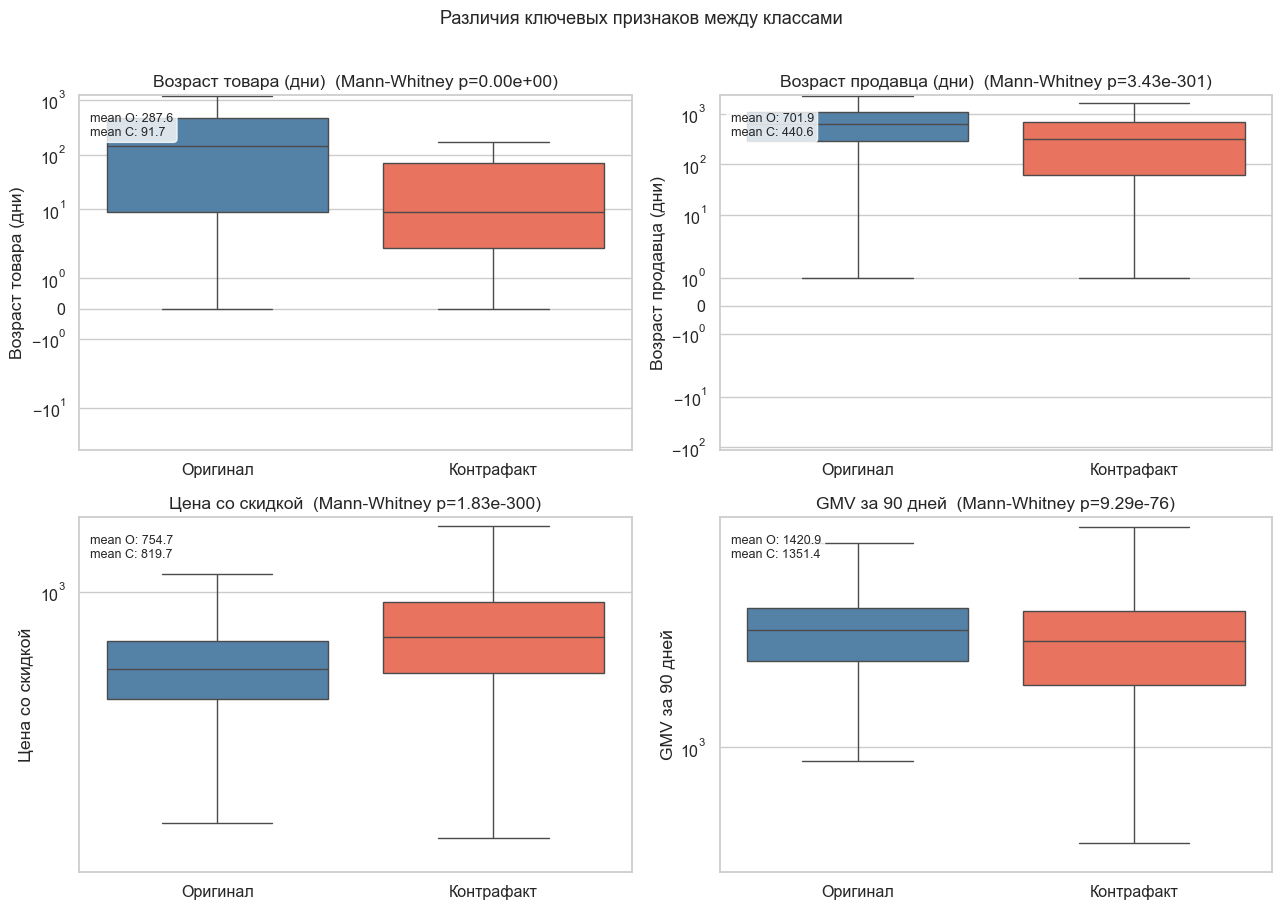


Главное: все распределения статистически различимы (p << 0.001), но сильно перекрываются →
   ни один признак сам по себе не разделяет классы → нужна мультимодальная модель


In [6]:
key_features = [
    ('item_time_alive', 'Возраст товара (дни)', 'log'),
    ('seller_time_alive', 'Возраст продавца (дни)', 'log'),
    ('PriceDiscounted', 'Цена со скидкой', 'log'),
    ('GmvTotal90', 'GMV за 90 дней', 'log'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (col, label, scale) in zip(axes.flatten(), key_features):
    data = df[df[col].notna() & (df[col] >= 0)].copy()
    data['cls_str'] = data[TARGET].map({0: 'Оригинал', 1: 'Контрафакт'})
    orig = data[data[TARGET] == 0][col]
    cnt = data[data[TARGET] == 1][col]

    # Mann-Whitney U test
    stat, pval = mannwhitneyu(
        orig.sample(min(len(orig), 30000), random_state=SEED),
        cnt.sample(min(len(cnt), 5000), random_state=SEED),
        alternative='two-sided'
    )

    sns.boxplot(
        data=data, x='cls_str', y=col, ax=ax, showfliers=False,
        palette={'Оригинал': 'steelblue', 'Контрафакт': 'tomato'},
        order=['Оригинал', 'Контрафакт'], hue='cls_str', legend=False,
    )
    if scale == 'log':
        ax.set_yscale('symlog')
    ax.set_xlabel('')
    ax.set_ylabel(label)
    ax.set_title(f'{label}  (Mann-Whitney p={pval:.2e})')

    ax.text(0.02, 0.95, f'mean O: {orig.mean():.1f}\nmean C: {cnt.mean():.1f}',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), fontsize=9)

plt.suptitle('Различия ключевых признаков между классами', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT / 'fig05_class_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nГлавное: все распределения статистически различимы (p << 0.001), но сильно перекрываются →')
print('   ни один признак сам по себе не разделяет классы → нужна мультимодальная модель')

## Блок 6: FADAML-feature: price_ratio (главный заимствованный признак)

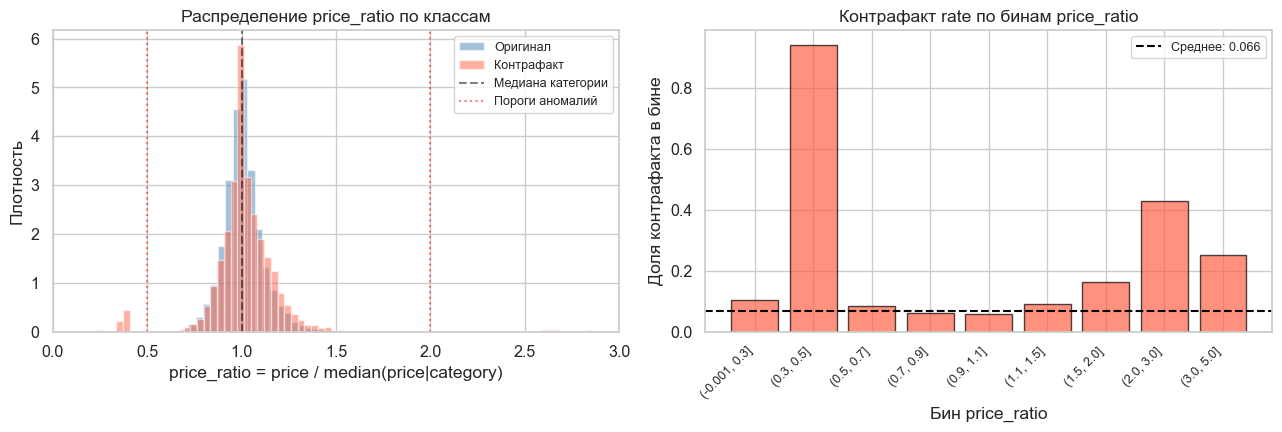


Главное: price_ratio имеет U-образную зависимость с целевой переменной — экстремально низкие
   (демпинг) и экстремально высокие (имитация премиума) цены чаще ассоциированы с контрафактом.
   Это и есть FADAML-сигнал (Nguyen et al. 2025), попавший в топ-9 SHAP финальной модели.


In [7]:
# Вычисляем price_ratio = price / median(price | category)
cat_median = df.groupby('CommercialTypeName4')['PriceDiscounted'].transform('median')
df['price_ratio'] = df['PriceDiscounted'].fillna(0) / cat_median.replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Распределение price_ratio по классам
valid = df[df['price_ratio'].notna() & (df['price_ratio'] > 0) & (df['price_ratio'] < 5)]
for cls, color, label in [(0, 'steelblue', 'Оригинал'), (1, 'tomato', 'Контрафакт')]:
    sub = valid[valid[TARGET] == cls]
    axes[0].hist(sub['price_ratio'], bins=80, alpha=0.5, density=True, color=color, label=label)
axes[0].axvline(1.0, color='black', linestyle='--', alpha=0.5, label='Медиана категории')
axes[0].axvline(0.5, color='red', linestyle=':', alpha=0.5)
axes[0].axvline(2.0, color='red', linestyle=':', alpha=0.5, label='Пороги аномалий')
axes[0].set_xlabel('price_ratio = price / median(price|category)')
axes[0].set_ylabel('Плотность')
axes[0].set_title('Распределение price_ratio по классам')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 3)

# Доля контрафакта по бинам price_ratio
bins = [0, 0.3, 0.5, 0.7, 0.9, 1.1, 1.5, 2.0, 3.0, 5.0]
df['pr_bin'] = pd.cut(df['price_ratio'], bins=bins, include_lowest=True)
by_bin = df.groupby('pr_bin')[TARGET].agg(['mean', 'count']).reset_index()
by_bin['pr_bin_str'] = by_bin['pr_bin'].astype(str)

axes[1].bar(range(len(by_bin)), by_bin['mean'], color='tomato', alpha=0.7, edgecolor='black')
axes[1].set_xticks(range(len(by_bin)))
axes[1].set_xticklabels(by_bin['pr_bin_str'], rotation=45, ha='right', fontsize=9)
axes[1].axhline(df[TARGET].mean(), color='black', linestyle='--', label=f'Среднее: {df[TARGET].mean():.3f}')
axes[1].set_xlabel('Бин price_ratio')
axes[1].set_ylabel('Доля контрафакта в бине')
axes[1].set_title('Контрафакт rate по бинам price_ratio')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT / 'fig06_price_ratio.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nГлавное: price_ratio имеет U-образную зависимость с целевой переменной — экстремально низкие')
print('   (демпинг) и экстремально высокие (имитация премиума) цены чаще ассоциированы с контрафактом.')
print('   Это и есть FADAML-сигнал (Nguyen et al. 2025), попавший в топ-9 SHAP финальной модели.')

## Блок 7: Анализ продавцов (объяснение, почему seller-based split необходим)

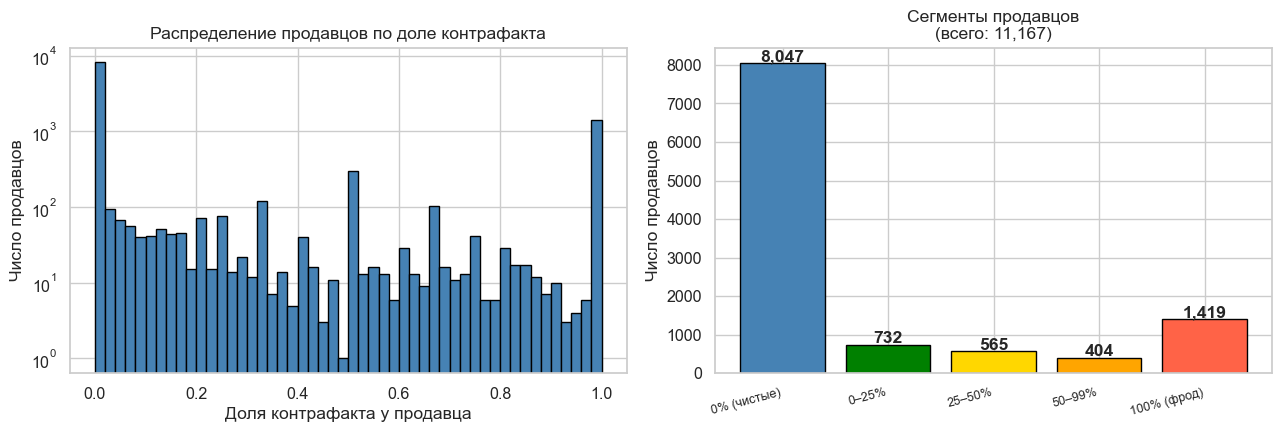


Корреляция seller_counterfeit_rate с target: 0.7935
Этот признак НЕЛЬЗЯ использовать без LOO-encoding — он несёт информацию о метке.


In [8]:
seller_stats = df.groupby('SellerID').agg(
    n_items=('id', 'count'),
    counterfeit_rate=(TARGET, 'mean'),
    counterfeit_count=(TARGET, 'sum'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Распределение counterfeit_rate по продавцам
axes[0].hist(seller_stats['counterfeit_rate'], bins=50, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Доля контрафакта у продавца')
axes[0].set_ylabel('Число продавцов')
axes[0].set_title('Распределение продавцов по доле контрафакта')
axes[0].set_yscale('log')

# Бинаризованное
buckets = [
    ('0% (чистые)', (seller_stats['counterfeit_rate'] == 0).sum()),
    ('0–25%', ((seller_stats['counterfeit_rate'] > 0) & (seller_stats['counterfeit_rate'] <= 0.25)).sum()),
    ('25–50%', ((seller_stats['counterfeit_rate'] > 0.25) & (seller_stats['counterfeit_rate'] <= 0.5)).sum()),
    ('50–99%', ((seller_stats['counterfeit_rate'] > 0.5) & (seller_stats['counterfeit_rate'] < 1)).sum()),
    ('100% (фрод)', (seller_stats['counterfeit_rate'] == 1).sum()),
]
names, counts = zip(*buckets)
axes[1].bar(names, counts, color=['steelblue', 'green', 'gold', 'orange', 'tomato'], edgecolor='black')
axes[1].set_ylabel('Число продавцов')
axes[1].set_title(f'Сегменты продавцов\n(всего: {len(seller_stats):,})')
for i, v in enumerate(counts):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')
plt.setp(axes[1].get_xticklabels(), rotation=15, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig(OUT / 'fig07_seller_segments.png', dpi=120, bbox_inches='tight')
plt.show()

# Корреляция признака seller_counterfeit_rate с target — иллюстрация проблемы leakage
df_with_seller_rate = df.merge(seller_stats[['SellerID', 'counterfeit_rate']],
                                 on='SellerID', how='left')
corr = df_with_seller_rate['counterfeit_rate'].corr(df_with_seller_rate[TARGET])
print(f'\nКорреляция seller_counterfeit_rate с target: {corr:.4f}')
print(f'Этот признак НЕЛЬЗЯ использовать без LOO-encoding — он несёт информацию о метке.')

**Ключевой вывод:** из 11 167 продавцов 72% «чистых» и ~13% полностью занимаются контрафактом. Признак `seller_counterfeit_rate` коррелирует с меткой на +0.79, но на test применять нельзя — для новых продавцов это значение неизвестно. Решение: LOO target encoding по бренду и категории.

## Блок 8: Корреляционная матрица топ-признаков

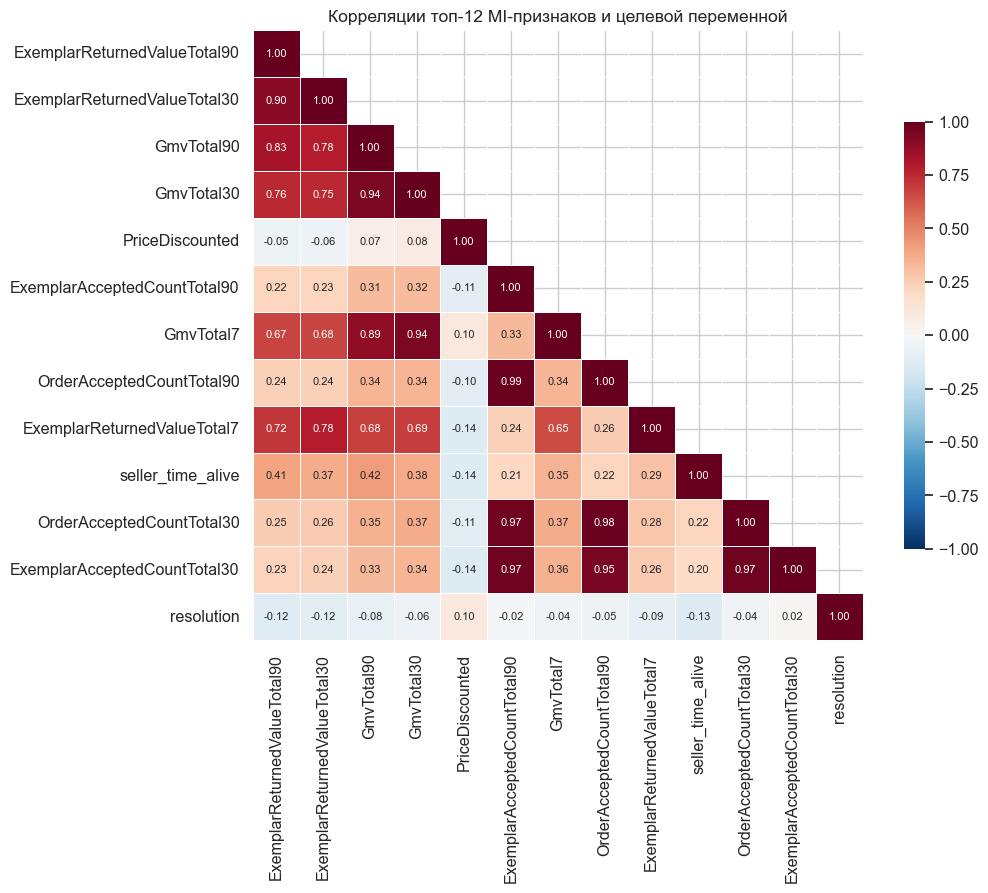

In [9]:
# Корреляция топ-MI признаков с target
top_features_for_corr = list(mi_df['feature'].head(12)) + [TARGET]
corr_matrix = df[top_features_for_corr].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.7}, ax=ax, annot_kws={'fontsize': 8})
ax.set_title('Корреляции топ-12 MI-признаков и целевой переменной')
plt.tight_layout()
plt.savefig(OUT / 'fig08_correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## Блок 9: Анализ изображений — почему image-only не работает на маркетплейсе

Items with CLIP embeddings: 187,604 / 197,198


Computing t-SNE (~30 sec)...


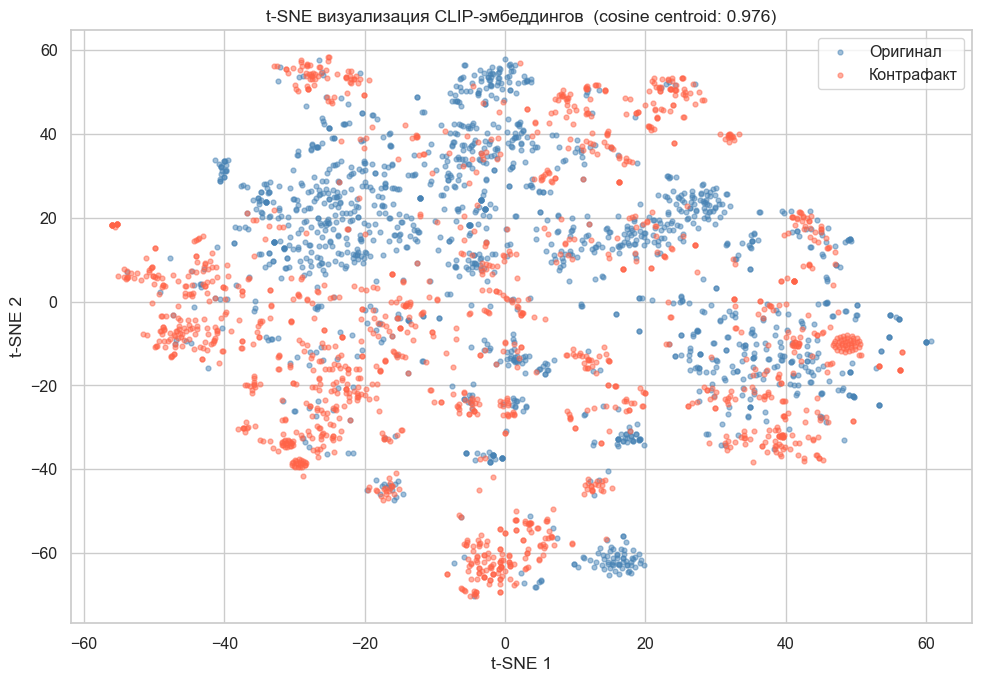


Главное: cosine между центроидами классов = 0.976 (близко к 1) →
   изображения контрафакта почти идентичны изображениям оригиналов (продавцы копируют фото)
   → image-only baseline даёт ROC-AUC только 0.853 (см. главу 3)


In [10]:
# CLIP embeddings
clip_path = ROOT / 'counterfeit_service' / 'clip_embeddings.parquet'
clip_df = pd.read_parquet(clip_path)
merged = df[['ItemID', TARGET]].merge(clip_df, on='ItemID', how='inner')
print(f'Items with CLIP embeddings: {len(merged):,} / {len(df):,}')

# Центроиды по классам и cosine между ними
X = np.vstack(merged['embedding'].values).astype(np.float32)
X_n = X / np.linalg.norm(X, axis=1, keepdims=True).clip(min=1e-8)

centroid_orig = X_n[merged[TARGET] == 0].mean(axis=0)
centroid_cnt = X_n[merged[TARGET] == 1].mean(axis=0)
centroid_cos = centroid_orig @ centroid_cnt / (
    np.linalg.norm(centroid_orig) * np.linalg.norm(centroid_cnt)
)

# t-SNE на сэмпле
from sklearn.manifold import TSNE
sample_size = 3000
balanced_idx = np.concatenate([
    np.random.default_rng(SEED).choice(np.where(merged[TARGET] == 0)[0], size=sample_size // 2, replace=False),
    np.random.default_rng(SEED).choice(np.where(merged[TARGET] == 1)[0], size=min(sample_size // 2, (merged[TARGET] == 1).sum()), replace=False),
])
print('Computing t-SNE (~30 sec)...')
X_tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_jobs=-1).fit_transform(X_n[balanced_idx])

fig, ax = plt.subplots(figsize=(10, 7))
y_sample = merged[TARGET].iloc[balanced_idx].to_numpy()
ax.scatter(X_tsne[y_sample == 0, 0], X_tsne[y_sample == 0, 1],
           c='steelblue', alpha=0.5, s=12, label='Оригинал')
ax.scatter(X_tsne[y_sample == 1, 0], X_tsne[y_sample == 1, 1],
           c='tomato', alpha=0.5, s=12, label='Контрафакт')
ax.set_title(f't-SNE визуализация CLIP-эмбеддингов  (cosine centroid: {centroid_cos:.3f})')
ax.legend(); ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig(OUT / 'fig09_clip_tsne.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nГлавное: cosine между центроидами классов = {centroid_cos:.3f} (близко к 1) →')
print('   изображения контрафакта почти идентичны изображениям оригиналов (продавцы копируют фото)')
print('   → image-only baseline даёт ROC-AUC только 0.853 (см. главу 3)')

## Блок 10: Текстовые сигналы и подозрительные ключевые слова

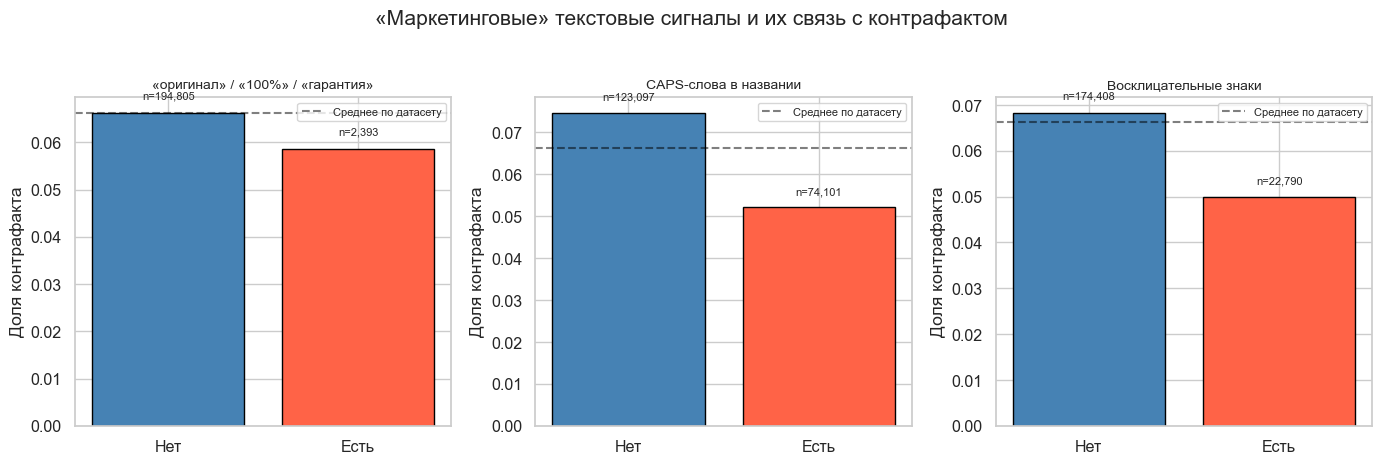


Главное: использование слов «оригинал» / «100%» / «гарантия» — парадоксально сильный сигнал
   контрафакта. Это и есть «manipulative marketing» паттерн из FADAML.


In [11]:
# Анализ susp_kw признака
name = df['name_rus'].fillna('').str.lower()
df['susp_kw'] = name.str.contains('оригинал|original|100%|гарантия', regex=True, na=False).astype(int)
df['has_caps_word'] = df['name_rus'].fillna('').str.contains(r'\b[А-ЯA-Z]{3,}\b', regex=True).astype(int)
df['has_exclamation'] = df['description'].fillna('').str.contains('!').astype(int)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (feat, label) in zip(axes, [
    ('susp_kw', '«оригинал» / «100%» / «гарантия»'),
    ('has_caps_word', 'CAPS-словa в названии'),
    ('has_exclamation', 'Восклицательные знаки'),
]):
    rates = df.groupby(feat)[TARGET].mean()
    counts = df.groupby(feat).size()
    bars = ax.bar(['Нет', 'Есть'], rates.values, color=['steelblue', 'tomato'], edgecolor='black')
    ax.axhline(df[TARGET].mean(), color='black', linestyle='--', alpha=0.5, label='Среднее по датасету')
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('Доля контрафакта')
    for i, (b, c) in enumerate(zip(bars, counts.values)):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.003,
                f'n={c:,}', ha='center', fontsize=8)
    ax.legend(fontsize=8)

plt.suptitle('«Маркетинговые» текстовые сигналы и их связь с контрафактом', y=1.03)
plt.tight_layout()
plt.savefig(OUT / 'fig10_text_signals.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nГлавное: использование слов «оригинал» / «100%» / «гарантия» — парадоксально сильный сигнал')
print('   контрафакта. Это и есть «manipulative marketing» паттерн из FADAML.')

## Блок 11: Сводная инфографика для финального слайда

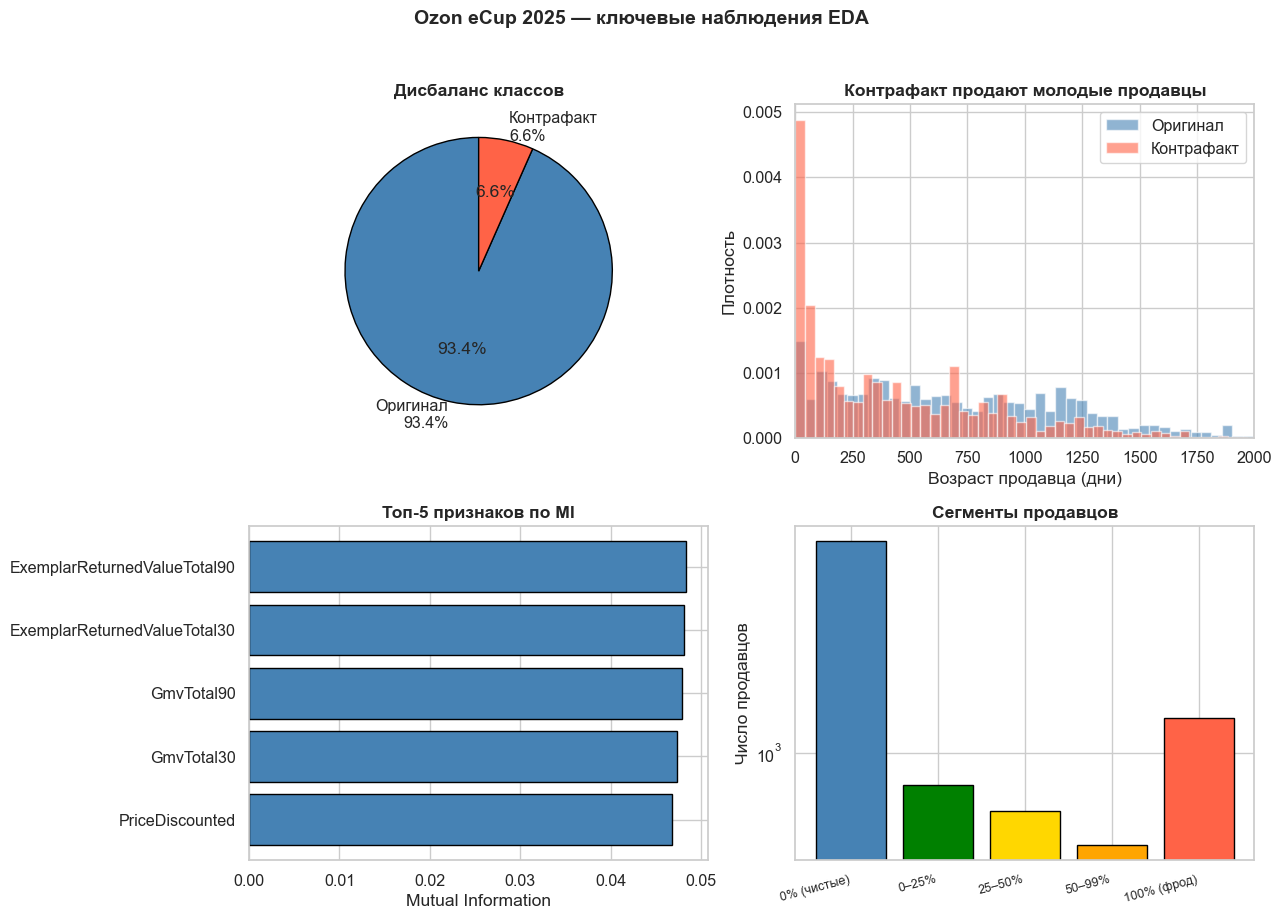

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Дисбаланс
axes[0, 0].pie([1 - df[TARGET].mean(), df[TARGET].mean()],
                labels=[f'Оригинал\n{1 - df[TARGET].mean():.1%}', f'Контрафакт\n{df[TARGET].mean():.1%}'],
                colors=['steelblue', 'tomato'], autopct='%1.1f%%', startangle=90,
                wedgeprops={'edgecolor': 'black'})
axes[0, 0].set_title('Дисбаланс классов', fontweight='bold')

# 2. Возраст продавца
for cls, color in [(0, 'steelblue'), (1, 'tomato')]:
    sub = df[df[TARGET] == cls]['seller_time_alive'].dropna()
    axes[0, 1].hist(sub, bins=50, alpha=0.6, color=color,
                    label='Оригинал' if cls == 0 else 'Контрафакт', density=True)
axes[0, 1].set_xlabel('Возраст продавца (дни)'); axes[0, 1].set_ylabel('Плотность')
axes[0, 1].set_title('Контрафакт продают молодые продавцы', fontweight='bold')
axes[0, 1].legend(); axes[0, 1].set_xlim(0, 2000)

# 3. Топ-5 MI
top5 = mi_df.head(5)
axes[1, 0].barh(top5['feature'][::-1], top5['MI'][::-1], color='steelblue', edgecolor='black')
axes[1, 0].set_xlabel('Mutual Information'); axes[1, 0].set_title('Топ-5 признаков по MI', fontweight='bold')

# 4. Сегменты продавцов
names, counts = zip(*buckets)
axes[1, 1].bar(names, counts, color=['steelblue', 'green', 'gold', 'orange', 'tomato'], edgecolor='black')
axes[1, 1].set_ylabel('Число продавцов'); axes[1, 1].set_title('Сегменты продавцов', fontweight='bold')
axes[1, 1].set_yscale('log')
plt.setp(axes[1, 1].get_xticklabels(), rotation=15, ha='right', fontsize=9)

plt.suptitle('Ozon eCup 2025 — ключевые наблюдения EDA', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'fig11_summary.png', dpi=120, bbox_inches='tight')
plt.show()

## Сводка наблюдений EDA (для финального слайда защиты)

| № | Наблюдение | Импликация для модели |
|---|---|---|
| 1 | Дисбаланс 14:1 (6.62% контрафакта) | PR-AUC и Recall@P — основные метрики, accuracy неприменима |
| 2 | Random split → утечка через SellerID | Обязательно seller-based split, иначе R@P завышен в 15× |
| 3 | Covariate shift (test rate 13% vs train 6%) | Требует робастности модели; обоснование bootstrap CI |
| 4 | Пропуски информативны (`photos_published_count`: 84% vs 75%) | NaN-флаги как признаки |
| 5 | Топ-MI: GmvTotal30/90, Returns* | Финансовые агрегаты — сильный сигнал |
| 6 | Контрафакт у молодых товаров и продавцов | `is_new_item`, `is_new_seller` — индикаторы |
| 7 | price_ratio U-образно: и низкие, и высокие цены | FADAML feature, попадает в топ-9 SHAP |
| 8 | seller_counterfeit_rate коррелирует с target +0.79 | НЕЛЬЗЯ использовать напрямую; LOO target encoding |
| 9 | CLIP-центроиды cosine ~0.98 | Image-only слабо разделим; нужна мультимодальность |
| 10 | Парадокс: слова «оригинал», «100%», «гарантия» — признаки контрафакта | Manipulative marketing-паттерн |
| 11 | 13% продавцов — фрод (100% контрафакт) | Поведенческие признаки продавца критичны |
| 12 | Нелинейные взаимодействия (MI высокий, корреляция средняя) | Нужен ансамбль (CatBoost / Random Forest) |

**Все графики сохранены в `eda_figures/`** — готовы для презентации защиты.